In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import joblib
pd.set_option("display.max_columns",None)

In [11]:
df = pd.read_csv(r"D:\SecurePay-AI\dataset\cleaned\transactions_clean.csv")

print("shape :" , df.shape)
df.head()

shape : (6362620, 11)


,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameorig        object 
 4   oldbalanceorg   float64
 5   newbalanceorig  float64
 6   namedest        object 
 7   oldbalancedest  float64
 8   newbalancedest  float64
 9   isfraud         int64  
 10  isflaggedfraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [13]:
required_columns = [
    "step",
    "type",
    "amount",
    "nameorig",
    "oldbalanceorg",
    "newbalanceorig",
    "namedest",
    "oldbalancedest",
    "newbalancedest",
    "isfraud"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("missing columns :",missing_columns)

missing columns : []


In [14]:
# sort transaction by time 
df = df.sort_values(
    by=["step"]
).reset_index(drop=True)

df[["step", "nameorig", "namedest", "amount", "isfraud"]].head(10)

,step,nameorig,namedest,amount,isfraud
0,1,C1231006815,M1979787155,9839.64,0
1,1,C1666544295,M2044282225,1864.28,0
2,1,C1305486145,C553264065,181.00,1
3,1,C840083671,C38997010,181.00,1
4,1,C2048537720,M1230701703,11668.14,0
5,1,C90045638,M573487274,7817.71,0
6,1,C154988899,M408069119,7107.77,0
7,1,C1912850431,M633326333,7861.64,0
8,1,C1265012928,M1176932104,4024.36,0
9,1,C712410124,C195600860,5337.77,0


In [15]:
# creating historical receiver feature 
df["receiver_trnsaction_count"]=(
    df.groupby("namedest").cumcount()
)

In [16]:
df[
    [
        "namedest",
        "receiver_trnsaction_count"
    ]
].head(10)

,namedest,receiver_trnsaction_count
0,M1979787155,0
1,M2044282225,0
2,C553264065,0
3,C38997010,0
4,M1230701703,0
5,M573487274,0
6,M408069119,0
7,M633326333,0
8,M1176932104,0
9,C195600860,0


In [17]:
# Check the exact column name
# print([
#     col for col in df.columns
#     if "receiver" in col.lower()
# ])
df.rename(
    columns={
        "receiver_trnsaction_count": "receiver_transaction_count"
    },
    inplace=True
)

In [18]:
# PREVIOUS RECEIVER FRAUD COUNT
df["previous_receiver_fraud"] = (
    df.groupby("namedest")["isfraud"].transform(lambda x: x.shift(1).fillna(0).cumsum())
)

In [19]:
df[["namedest","isfraud","receiver_transaction_count","previous_receiver_fraud"]].head(10)

,namedest,isfraud,receiver_transaction_count,previous_receiver_fraud
0,M1979787155,0,0,0.0
1,M2044282225,0,0,0.0
2,C553264065,1,0,0.0
3,C38997010,1,0,0.0
4,M1230701703,0,0,0.0
5,M573487274,0,0,0.0
6,M408069119,0,0,0.0
7,M633326333,0,0,0.0
8,M1176932104,0,0,0.0
9,C195600860,0,0,0.0


In [20]:
# historical receiver fraud rate
df["historical_receiver_fraud_rate"] = np.where(
    df["receiver_transaction_count"] > 0,
    df["previous_receiver_fraud"] /
    df["receiver_transaction_count"],
    0
)

In [21]:
df[
    [
        "namedest",
        "receiver_transaction_count",
        "previous_receiver_fraud",
        "historical_receiver_fraud_rate"
    ]
].head(20)

,namedest,receiver_transaction_count,previous_receiver_fraud,historical_receiver_fraud_rate
0,M1979787155,0,0.0,0.0
1,M2044282225,0,0.0,0.0
2,C553264065,0,0.0,0.0
3,C38997010,0,0.0,0.0
4,M1230701703,0,0.0,0.0
5,M573487274,0,0.0,0.0
6,M408069119,0,0.0,0.0
7,M633326333,0,0.0,0.0
8,M1176932104,0,0.0,0.0
9,C195600860,0,0.0,0.0


In [22]:
# previous receiver amount 
df["previous_receiver_amount"] = (
    df.groupby("namedest")["amount"].transform(lambda x:x.shift(1).fillna(0).cumsum())
)

In [23]:
df[["namedest","amount","previous_receiver_amount"]].head(20)

,namedest,amount,previous_receiver_amount
0,M1979787155,9839.64,0.0
1,M2044282225,1864.28,0.0
2,C553264065,181.00,0.0
3,C38997010,181.00,0.0
4,M1230701703,11668.14,0.0
5,M573487274,7817.71,0.0
6,M408069119,7107.77,0.0
7,M633326333,7861.64,0.0
8,M1176932104,4024.36,0.0
9,C195600860,5337.77,0.0


In [24]:
# historical sender transaction count 

df["sender_transaction_count"] =(
    df.groupby("nameorig").cumcount()
)

In [25]:
df[["nameorig","sender_transaction_count"]].head(20)

,nameorig,sender_transaction_count
0,C1231006815,0
1,C1666544295,0
2,C1305486145,0
3,C840083671,0
4,C2048537720,0
5,C90045638,0
6,C154988899,0
7,C1912850431,0
8,C1265012928,0
9,C712410124,0


In [26]:
df["previous_sender_amount"] = (
    df.groupby("nameorig")["amount"]
      .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

In [27]:
print(df["previous_sender_amount"].dtype)

float64


In [28]:
df[
    [
        "nameorig",
        "amount",
        "previous_sender_amount"
    ]
].head(20)

,nameorig,amount,previous_sender_amount
0,C1231006815,9839.64,0.0
1,C1666544295,1864.28,0.0
2,C1305486145,181.00,0.0
3,C840083671,181.00,0.0
4,C2048537720,11668.14,0.0
5,C90045638,7817.71,0.0
6,C154988899,7107.77,0.0
7,C1912850431,7861.64,0.0
8,C1265012928,4024.36,0.0
9,C712410124,5337.77,0.0


In [29]:
# sender balance change
df["sender_balance_change"]=(
    df["oldbalanceorg"] -
    df["newbalanceorig"]
)

In [30]:
df[
    [
        "oldbalanceorg",
        "newbalanceorig",
        "sender_balance_change"
    ]
].head(20)

,oldbalanceorg,newbalanceorig,sender_balance_change
0,170136.00,160296.36,9839.64
1,21249.00,19384.72,1864.28
2,181.00,0.00,181.00
3,181.00,0.00,181.00
4,41554.00,29885.86,11668.14
5,53860.00,46042.29,7817.71
6,183195.00,176087.23,7107.77
7,176087.23,168225.59,7861.64
8,2671.00,0.00,2671.00
9,41720.00,36382.23,5337.77


In [31]:
# receiver balance change 
df["receiver_balance_change"] =(
    df["newbalancedest"] -
    df["oldbalancedest"]
)

In [32]:
df[
    [
        "oldbalancedest",
        "newbalancedest",
        "receiver_balance_change"
    ]
].head(20)

,oldbalancedest,newbalancedest,receiver_balance_change
0,0.0,0.00,0.00
1,0.0,0.00,0.00
2,0.0,0.00,0.00
3,21182.0,0.00,-21182.00
4,0.0,0.00,0.00
5,0.0,0.00,0.00
6,0.0,0.00,0.00
7,0.0,0.00,0.00
8,0.0,0.00,0.00
9,41898.0,40348.79,-1549.21


In [33]:
# balance ration : this measure the transaction amount relative to the sender's previous balance

df["balance_ratio"] =(
    df["amount"] /
    (df["oldbalanceorg"]+1)
)

In [34]:
df[
    [
        "amount",
        "oldbalanceorg",
        "balance_ratio"
    ]
].head(10)

,amount,oldbalanceorg,balance_ratio
0,9839.64,170136.00,0.057834
1,1864.28,21249.00,0.087731
2,181.00,181.00,0.994505
3,181.00,181.00,0.994505
4,11668.14,41554.00,0.280788
5,7817.71,53860.00,0.145146
6,7107.77,183195.00,0.038799
7,7861.64,176087.23,0.044646
8,4024.36,2671.00,1.506123
9,5337.77,41720.00,0.127940


In [35]:
# time feature and transactionn behavior 
# extract hour

df["hour"] = df["step"] % 24
df[["step","hour"]].head(20)

,step,hour
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [36]:
# create day
df["day"] = df["step"] // 24
df[["step","day"]].head(20)

,step,day
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,1,0
6,1,0
7,1,0
8,1,0
9,1,0


In [37]:
# night transaction : we will mark transaction occuring during hours 0-5

df["night_transaction"]=(
    df["hour"].between(0,5)
).astype(int)

In [38]:
df[
    ["hour","night_transaction"]
].head(20)

,hour,night_transaction
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [39]:
# large transaction feature : createing a binary feature for unusually large transactions 

df["large_transaction"]=(
    df["amount"]>100000
).astype(int)

df[
    ["amount","large_transaction"]
].head(20)

,amount,large_transaction
0,9839.64,0
1,1864.28,0
2,181.00,0
3,181.00,0
4,11668.14,0
5,7817.71,0
6,7107.77,0
7,7861.64,0
8,4024.36,0
9,5337.77,0


In [40]:
# historical receiver risk score 
#now we will combine the historical receiver information we have created

# receiver transaction score
df["receiver_transaction_score"]=(
    df["receiver_transaction_count"]/
    df["receiver_transaction_count"].max()
)

In [41]:
# receiver amount score 
df["receiver_amount_score"]=(
    df["previous_receiver_amount"]/
    df["previous_receiver_amount"].max()
)

In [42]:
# calaculation of risk score 
df["historical_receiver_risk_score"]=(
    df["historical_receiver_fraud_rate"]*60
    + df["receiver_transaction_score"]*20
    + df["receiver_amount_score"]
)

In [43]:
df["historical_receiver_risk_score"]=(
    df["historical_receiver_risk_score"].round(2)
)

In [44]:
new_features = [
    "receiver_transaction_count",
    "previous_receiver_fraud",
    "historical_receiver_fraud_rate",
    "previous_receiver_amount",
    "sender_transaction_count",
    "previous_sender_amount",
    "sender_balance_change",
    "receiver_balance_change",
    "balance_ratio",
    "hour",
    "day",
    "night_transaction",
    "large_transaction",
    "historical_receiver_risk_score"
]

df[new_features].head(5)

,receiver_transaction_count,previous_receiver_fraud,historical_receiver_fraud_rate,previous_receiver_amount,sender_transaction_count,previous_sender_amount,sender_balance_change,receiver_balance_change,balance_ratio,hour,day,night_transaction,large_transaction,historical_receiver_risk_score
0,0,0.0,0.0,0.0,0,0.0,9839.64,0.0,0.057834,1,0,1,0,0.0
1,0,0.0,0.0,0.0,0,0.0,1864.28,0.0,0.087731,1,0,1,0,0.0
2,0,0.0,0.0,0.0,0,0.0,181.00,0.0,0.994505,1,0,1,0,0.0
3,0,0.0,0.0,0.0,0,0.0,181.00,-21182.0,0.994505,1,0,1,0,0.0
4,0,0.0,0.0,0.0,0,0.0,11668.14,0.0,0.280788,1,0,1,0,0.0


In [45]:
df[new_features].isnull().sum()

receiver_transaction_count        0
previous_receiver_fraud           0
historical_receiver_fraud_rate    0
previous_receiver_amount          0
sender_transaction_count          0
previous_sender_amount            0
sender_balance_change             0
receiver_balance_change           0
balance_ratio                     0
hour                              0
day                               0
night_transaction                 0
large_transaction                 0
historical_receiver_risk_score    0
dtype: int64

In [46]:
# selecting final feature 

features =[
    "type",
    "amount",
    "oldbalanceorg",
    "newbalanceorig",
    "oldbalancedest",
    "newbalancedest",
    "large_transaction",
    "sender_transaction_count",
    "previous_sender_amount",

    "receiver_transaction_count",
    "previous_receiver_amount",
    "previous_receiver_fraud",
    "historical_receiver_fraud_rate",

    "sender_balance_change",
    "receiver_balance_change",
    "balance_ratio",

    "hour",
    "night_transaction",

    "historical_receiver_risk_score"
]

In [47]:
# now creating x,y 

X = df[features].copy()
y = df["isfraud"].copy()


In [48]:
print("x shape :",X.shape)
print("y shape ;",y.shape)

x shape : (6362620, 19)
y shape ; (6362620,)


In [49]:
X.isnull().sum()

type                              0
amount                            0
oldbalanceorg                     0
newbalanceorig                    0
oldbalancedest                    0
newbalancedest                    0
large_transaction                 0
sender_transaction_count          0
previous_sender_amount            0
receiver_transaction_count        0
previous_receiver_amount          0
previous_receiver_fraud           0
historical_receiver_fraud_rate    0
sender_balance_change             0
receiver_balance_change           0
balance_ratio                     0
hour                              0
night_transaction                 0
historical_receiver_risk_score    0
dtype: int64

In [50]:
y.isnull().sum()

np.int64(0)

In [51]:
print("Total features:", len(features))
print("Target:", y.name)

Total features: 19
Target: isfraud


In [52]:
# encode transaction type 
# type is categorical so encode it 

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [53]:
print(type(encoder))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [54]:
X["type"] = encoder.fit_transform(X["type"])

In [55]:
print("original transaction types :")
print(encoder.classes_)
print("\nEncoded values :")
print(X["type"].head(10))

original transaction types :
['CASH_IN' 'CASH_OUT' 'DEBIT' 'PAYMENT' 'TRANSFER']

Encoded values :
0    3
1    3
2    4
3    1
4    3
5    3
6    3
7    3
8    3
9    2
Name: type, dtype: int64


In [56]:
# time aware train / test split 
# for a fraud detection system we dont want to randomly mix future transaction inti the training data . our dataframe is already sorted 
# 80% eairlist transaction > training 
# 20% latest transactions > testing 

split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [57]:
print("training shape :", X_train.shape)
print("testing shape :",X_test.shape)

training shape : (5090096, 19)
testing shape : (1272524, 19)


In [58]:
# verifying the time split 

print("training step range :",
      df["step"].iloc[:split_index].min(),
      "to",
      df["step"].iloc[:split_index].max())

print(
    "testing step range :",
    df["step"].iloc[split_index].min(),
    "to",
    df["step"].iloc[split_index].max()
)

training step range : 1 to 355
testing step range : 355 to 355


In [59]:
# checking fraud distribution 
print("training fraud:")
print(y_train.value_counts())
print("\ntesting fraud:")
print(y_test.value_counts())

training fraud:
isfraud
0    5086137
1       3959
Name: count, dtype: int64

testing fraud:
isfraud
0    1268270
1       4254
Name: count, dtype: int64


In [60]:
print(
    "\nTraining fraud percentage:",
    y_train.mean() * 100
)

print(
    "Testing fraud percentage:",
    y_test.mean() * 100
)

# if percentage arent exact identical because we are using a time based split the distribuition can naturally change over time  that's actually useful beacuse it tests whether the model cam generalize to future transations


Training fraud percentage: 0.07777849376514706
Testing fraud percentage: 0.33429624902948785


In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [63]:
rf_final.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [64]:
y_pred = rf_final.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 1, 1], shape=(1272524,))

In [65]:
y_prob = rf_final.predict_proba(X_test)[:, 1]

In [66]:
# prediction count 
print("test transaction :" , len(y_test))
print("predictions :" , len(y_pred))

test transaction : 1272524
predictions : 1272524


In [67]:
# okay then now evaluate the model 
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test , y_pred)
precision = precision_score(y_test,y_pred,zero_division=0)
recall = recall_score(y_test,y_pred,zero_division=0)
f1 = f1_score(y_test,y_pred,zero_division=0)

print("accuracy :", accuracy)
print("precision :",precision)
print("recall :",recall)
print("f1 score :",f1)

accuracy : 0.9999960708010223
precision : 1.0
recall : 0.9988246356370475
f1 score : 0.9994119722450899


In [68]:
# classificationn report 

from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal","Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1268270
       Fraud       1.00      1.00      1.00      4254

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [69]:
# cnfusion matrix 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[1268270       0]
 [      5    4249]]


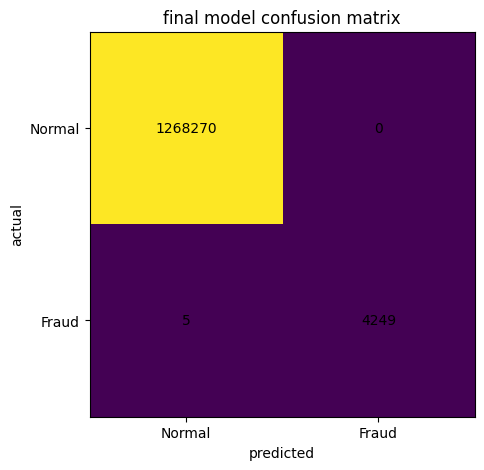

In [70]:
plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title("final model confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.xticks([0,1],["Normal","Fraud"])
plt.yticks([0,1],["Normal","Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.show()

In [71]:
# compare old vs final model 

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Previous Model": [
        0.99999607,
        1.0,
        0.99695679,
        0.99847607
    ],
    "Final Model": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison

,Metric,Previous Model,Final Model
0,Accuracy,0.999996,0.999996
1,Precision,1.000000,1.000000
2,Recall,0.996957,0.998825
3,F1 Score,0.998476,0.999412


In [72]:
comparison["Previous Model"] = (
    comparison["Previous Model"] * 100
).round(6)

comparison["Final Model"] = (
    comparison["Final Model"] * 100
).round(6)

comparison

,Metric,Previous Model,Final Model
0,Accuracy,99.999607,99.999607
1,Precision,100.000000,100.000000
2,Recall,99.695679,99.882464
3,F1 Score,99.847607,99.941197


In [73]:
# feature importance : this is important for our securepay ai because we want to know why the model consider a transaction risky

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_final.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance 

,feature,importance
15,balance_ratio,2.951153e-01
13,sender_balance_change,2.513296e-01
3,newbalanceorig,1.166708e-01
2,oldbalanceorg,1.115766e-01
0,type,6.196776e-02
1,amount,4.513024e-02
14,receiver_balance_change,3.130642e-02
16,hour,2.652766e-02
6,large_transaction,1.646793e-02
5,newbalancedest,1.256873e-02


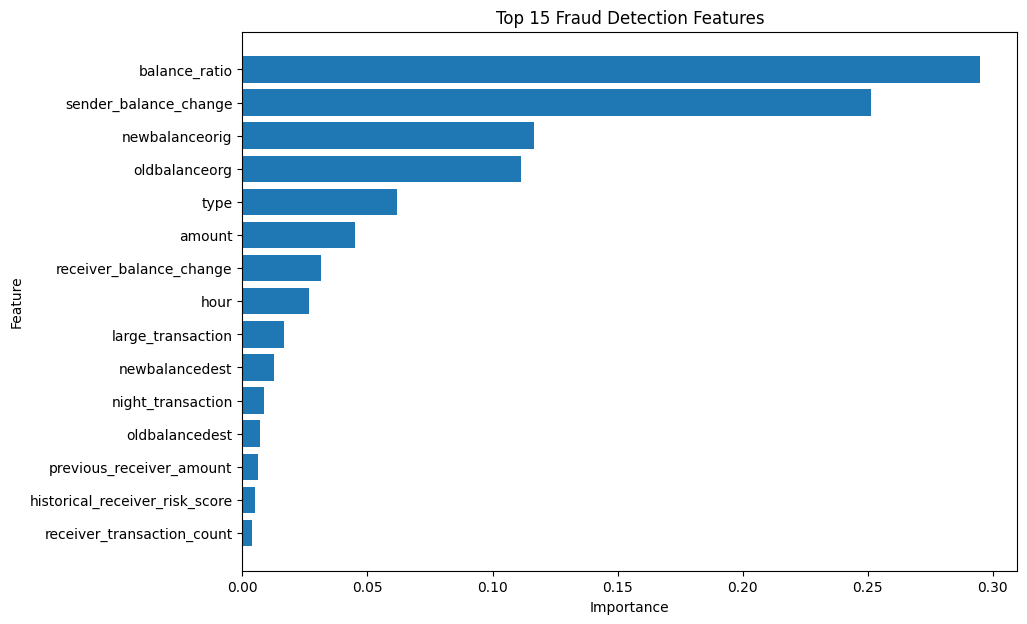

In [74]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance["feature"].head(15)[::-1],
    importance["importance"].head(15)[::-1]
)

plt.title("Top 15 Fraud Detection Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [75]:
import os
joblib.dump(
    rf_final,
    r"D:\SecurePay-AI\ml\models\fraud_model.pkl"
)

['D:\\SecurePay-AI\\ml\\models\\fraud_model.pkl']

In [76]:
joblib.dump(
    encoder,
    r"D:\SecurePay-AI\ml\models\label_encoder.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    r"D:\SecurePay-AI\ml\models\feature_columns.pkl"
)

['D:\\SecurePay-AI\\ml\\models\\feature_columns.pkl']

In [77]:
print(os.listdir(r"D:\SecurePay-AI\ml\models"))

['feature_columns.pkl', 'fraud_model.pkl', 'label_encoder.pkl', 'scaler.pkl']
